In [14]:
# cifar10_nn_numpy

import numpy as np
import pickle
import os
import matplotlib.pyplot as plt

### --- Activation Functions --- ###
"""
提前定义激活函数
"""
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_grad(x):
    s = sigmoid(x)
    return s * (1 - s)

def softmax(x):
    x -= np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy_loss(probs, y_true):
    N = probs.shape[0]
    correct_logprobs = -np.log(probs[np.arange(N), y_true] + 1e-8)
    return np.mean(correct_logprobs)

In [15]:
### --- Model --- ###
"""神经网络结构"""
class ThreeLayerNet:
    def __init__(self, input_dim, hidden_dim, output_dim, activation='relu', weight_scale=1e-3, reg=0.0):
        self.params = {}
        self.reg = reg
        self.activation_name = activation

        self.params['W1'] = weight_scale * np.random.randn(input_dim, hidden_dim)
        self.params['b1'] = np.zeros(hidden_dim)
        self.params['W2'] = weight_scale * np.random.randn(hidden_dim, output_dim)
        self.params['b2'] = np.zeros(output_dim)

    def _activation(self, x):
        return relu(x) if self.activation_name == 'relu' else sigmoid(x)

    def _activation_grad(self, x):
        return relu_grad(x) if self.activation_name == 'relu' else sigmoid_grad(x)

    def forward(self, X, y=None):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']

        #线性层1
        z1 = X @ W1 + b1
        #激活层
        a1 = self._activation(z1)
        #线性层2
        scores = a1 @ W2 + b2
        #softmax处理分类问题
        probs = softmax(scores)

        if y is None:
            return probs

        
        loss = cross_entropy_loss(probs, y)
        loss += 0.5 * self.reg * (np.sum(W1**2) + np.sum(W2**2))

        grads = {}
        N = X.shape[0]
        dscores = probs
        dscores[np.arange(N), y] -= 1
        dscores /= N

        grads['W2'] = a1.T @ dscores + self.reg * W2
        grads['b2'] = np.sum(dscores, axis=0)

        da1 = dscores @ W2.T
        dz1 = da1 * self._activation_grad(z1)

        grads['W1'] = X.T @ dz1 + self.reg * W1
        grads['b1'] = np.sum(dz1, axis=0)

        return loss, grads

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

In [16]:
### --- Optimizer --- ###
"""优化器"""
def sgd_update(params, grads, learning_rate):
    for key in params:
        params[key] -= learning_rate * grads[key]

### --- Data Utils --- ###
"""数据加载"""
def load_cifar_batch(filename):
    with open(filename, 'rb') as f:
        datadict = pickle.load(f, encoding='bytes')
        X = datadict[b'data'].reshape(10000, 3, 32, 32).astype("float")
        y = np.array(datadict[b'labels'])
        return X, y

def load_cifar10(root):
    xs, ys = [], []
    for i in range(1, 6):
        f = os.path.join(root, f"data_batch_{i}")
        X, y = load_cifar_batch(f)
        xs.append(X)
        ys.append(y)
    X_train = np.concatenate(xs)
    y_train = np.concatenate(ys)
    X_test, y_test = load_cifar_batch(os.path.join(root, 'test_batch'))
    return X_train, y_train, X_test, y_test

def preprocess(X):
    X = X / 255.0
    return X.reshape(X.shape[0], -1)

In [17]:
### --- Train --- ###
"""训练函数"""
def train(model, X_train, y_train, X_val, y_val,
          num_epochs=10, batch_size=100, learning_rate=1e-3, lr_decay=0.95,decay_start_epoch=10):
    best_val_acc = 0.0
    best_params = None
    train_loss_hist, val_acc_hist = [], []

    for epoch in range(num_epochs):
        # Shuffle
        indices = np.arange(X_train.shape[0])
        np.random.shuffle(indices)
        X_train, y_train = X_train[indices], y_train[indices]

        # 每个小批次的训练
        for i in range(0, X_train.shape[0], batch_size):
            X_batch = X_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]

            loss, grads = model.forward(X_batch, y_batch)
            sgd_update(model.params, grads, learning_rate)
            train_loss_hist.append(loss)

        # 当前批次的评估值
        val_preds = model.predict(X_val)
        val_acc = np.mean(val_preds == y_val)
        val_acc_hist.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs}, Val Acc: {val_acc:.4f}, LR: {learning_rate:.5f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_params = {k: v.copy() for k, v in model.params.items()}

        #learning_rate *= lr_decay
        
        if epoch >= decay_start_epoch:
            learning_rate *= lr_decay

    model.params = best_params
    return train_loss_hist, val_acc_hist

In [18]:
### --- Test --- ###
"""测试函数"""
def test(model, X_test, y_test):
    preds = model.predict(X_test)
    acc = np.mean(preds == y_test)
    print("Test Accuracy:", acc)
    return acc

### --- Hyperparameter Search --- ###
def hyperparameter_search(X_train, y_train, X_val, y_val):
    hidden_sizes = [64, 128]
    learning_rates = [1e-3, 1e-2]
    regs = [0.0, 0.1]

    best_acc = 0
    best_config = None

    for h in hidden_sizes:
        for lr in learning_rates:
            for reg in regs:
                print(f"Training with hidden={h}, lr={lr}, reg={reg}")
                model = ThreeLayerNet(3072, h, 10, reg=reg)
                train(model, X_train, y_train, X_val, y_val,
                      num_epochs=3, learning_rate=lr)
                val_preds = model.predict(X_val)
                acc = np.mean(val_preds == y_val)
                print("Val Acc:", acc)

                if acc > best_acc:
                    best_acc = acc
                    best_config = (h, lr, reg)

    print("Best Config:", best_config)
    

In [19]:
### --- Visualizations --- ###
"""可视化"""


def plot_training(loss_hist, val_acc_hist):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(loss_hist)
    plt.title("Training Loss")
    plt.subplot(1, 2, 2)
    plt.plot(val_acc_hist)
    plt.title("Validation Accuracy")
    plt.show()

def visualize_weights(model):
    W = model.params['W1']
    fig, axes = plt.subplots(4, 8, figsize=(8, 4))
    for i, ax in enumerate(axes.flat):
        if i < W.shape[1]:
            img = W[:, i].reshape(3, 32, 32).transpose(1, 2, 0)
            
            # 归一化到 [0, 1] 区间
            img = img - img.min()
            img = img / (img.max() + 1e-5)  # 加一个小常数防止除以 0
            
            ax.imshow(img)
            ax.axis('off')
    plt.suptitle("First Layer Weights")
    plt.show()
    

Epoch 1/40, Val Acc: 0.3228, LR: 0.07000
Epoch 2/40, Val Acc: 0.3666, LR: 0.07000
Epoch 3/40, Val Acc: 0.3760, LR: 0.07000
Epoch 4/40, Val Acc: 0.3986, LR: 0.07000
Epoch 5/40, Val Acc: 0.4350, LR: 0.07000
Epoch 6/40, Val Acc: 0.4164, LR: 0.07000
Epoch 7/40, Val Acc: 0.4476, LR: 0.07000
Epoch 8/40, Val Acc: 0.4482, LR: 0.07000
Epoch 9/40, Val Acc: 0.4660, LR: 0.07000
Epoch 10/40, Val Acc: 0.4492, LR: 0.06650
Epoch 11/40, Val Acc: 0.4798, LR: 0.06317
Epoch 12/40, Val Acc: 0.4606, LR: 0.06002
Epoch 13/40, Val Acc: 0.4680, LR: 0.05702
Epoch 14/40, Val Acc: 0.4854, LR: 0.05416
Epoch 15/40, Val Acc: 0.4536, LR: 0.05146
Epoch 16/40, Val Acc: 0.4774, LR: 0.04888
Epoch 17/40, Val Acc: 0.4782, LR: 0.04644
Epoch 18/40, Val Acc: 0.4968, LR: 0.04412
Epoch 19/40, Val Acc: 0.4942, LR: 0.04191
Epoch 20/40, Val Acc: 0.4904, LR: 0.03982
Epoch 21/40, Val Acc: 0.5010, LR: 0.03783
Epoch 22/40, Val Acc: 0.5002, LR: 0.03593
Epoch 23/40, Val Acc: 0.5180, LR: 0.03414
Epoch 24/40, Val Acc: 0.5066, LR: 0.03243
E

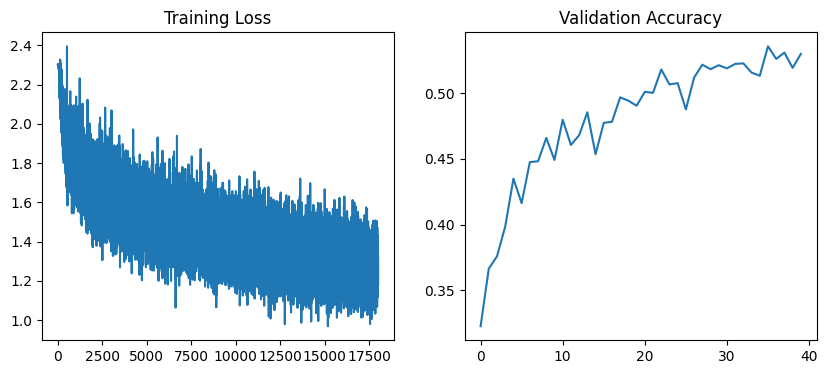

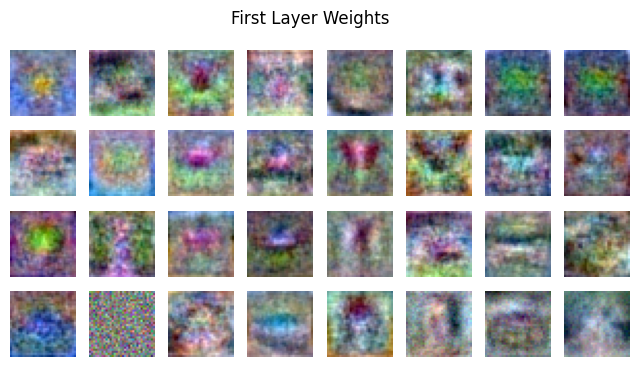

In [27]:
### --- Run Main --- ###
if __name__ == '__main__':
    cifar_path = '/Users/a1-6/Downloads/cifar-10-batches-py'  # 改为你的路径
    X_train_all, y_train_all, X_test, y_test = load_cifar10(cifar_path)
    X_train_all = preprocess(X_train_all)
    X_test = preprocess(X_test)

    # 划分验证集
    num_val = 5000
    X_val = X_train_all[:num_val]
    y_val = y_train_all[:num_val]
    X_train = X_train_all[num_val:]
    y_train = y_train_all[num_val:]

    model = ThreeLayerNet(3072, 128, 10, activation='relu',reg=1e-3)
    loss_hist, val_acc_hist = train(model, X_train, y_train, X_val, y_val,
                                    num_epochs=40, learning_rate=0.07,lr_decay=0.95,decay_start_epoch=8)
    test(model, X_test, y_test)
    plot_training(loss_hist, val_acc_hist)
    visualize_weights(model)